## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Park

**Date:** 10/2/2026

Q1

1. Regression predicts a numerical value, like someone's income or the price of a house. Classification predicts a category or label, like whether an email is spam or not.

2. A confusion table compares the model's predictions to the actual values. It shows how many predictions were correct and incorrect, and helps us see which classes the model tends to mix up.

3. SSE (Sum of Squared Errors) measures how far a model's predicted values are from the actual values by squaring the differences and adding them together. A lower SSE generally means the model has smaller prediction errors.

4. Overfitting is when a model follows the training data too closely and doesn't perform well on new data. Underfitting is when a model is too simple and fails to capture important patterns in the data. For kNN, a very small k can lead to overfitting, while a very large k can lead to underfitting.

5. Splitting the data lets us see how well the model performs on data it hasn't trained on. By comparing different values of k using accuracy or SSE, we can find one that performs well on new data instead of just the training data. Ideally, we would also keep a separate final test set that isn't used to choose k.

6. A class label gives one clear prediction, which makes it easy to understand, but it doesn't show how confident the model is. A probability distribution shows the estimated chance of each class, giving us more information about uncertainty. However, it can be harder to interpret, and the probabilities are only estimates, not guarantees.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/land_mines.csv")

print(df.head())
print(df.shape)
print(df.isna().sum())
print(df["mine_type"].value_counts().sort_index())
print(df[["voltage", "height", "soil"]].describe().round(3))

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000


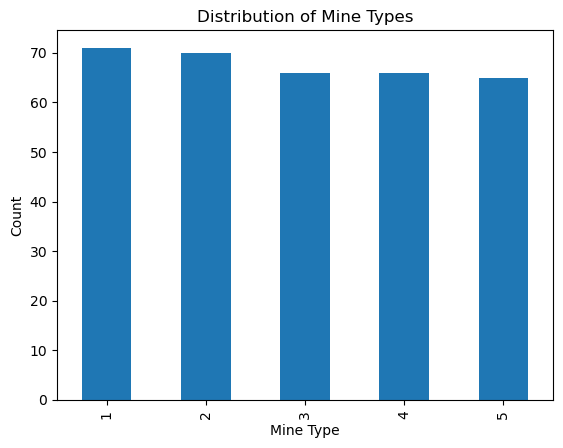

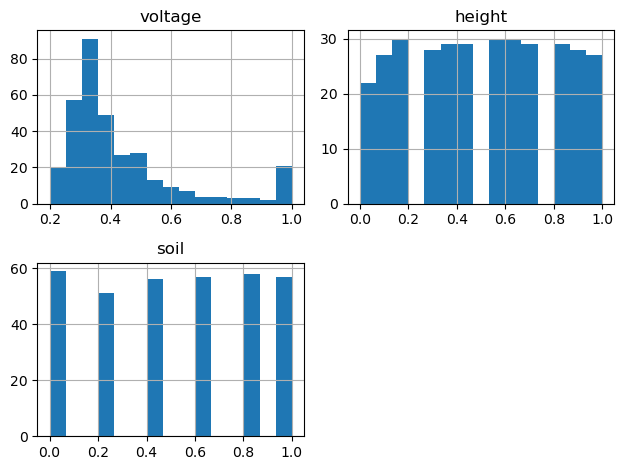

In [5]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.title("Distribution of Mine Types")
plt.show()

df[["voltage", "height", "soil"]].hist(bins=15)

plt.tight_layout()
plt.show()

The dataset has 338 observations and no missing values. There are three features (voltage, height, and soil) and five possible mine types.

The mine types are distributed pretty evenly, with each class having between 65 and 71 observations. All three features have values between 0 and 1, although voltage doesn't go all the way down to 0.

Since mine_type represents a category rather than a continuous number, I'll use classification instead of regression.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.5, random_state=65
)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print("Training size:", len(X_train))
print("Validation size:", len(X_valid))

print(y_train.value_counts().sort_index())
print(y_valid.value_counts().sort_index())

Training size: 169
Validation size: 169
mine_type
1    37
2    32
3    36
4    28
5    36
Name: count, dtype: int64
mine_type
1    34
2    38
3    30
4    38
5    29
Name: count, dtype: int64


The split gives me 169 observations for training and 169 for validation. All five mine types are represented in both sets, so the model has examples of every class to learn from.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 51)

train_accuracies = []
valid_accuracies = []

for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=int(k))
    candidate.fit(X_train, y_train)

    train_hat = candidate.predict(X_train)
    valid_hat = candidate.predict(X_valid)

    train_accuracy = np.mean(train_hat == y_train.to_numpy())
    valid_accuracy = np.mean(valid_hat == y_valid.to_numpy())

    train_accuracies.append(train_accuracy)
    valid_accuracies.append(valid_accuracy)

best_k = int(ks[np.argmax(valid_accuracies)])

print("Best k:", best_k)
print("Best validation accuracy:", max(valid_accuracies))

Best k: 2
Best validation accuracy: 0.44970414201183434


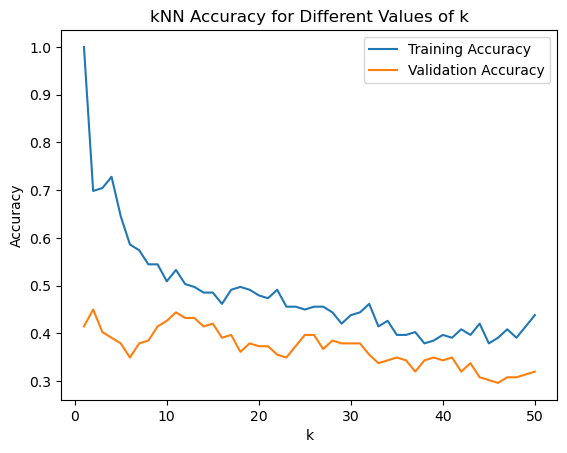

In [8]:
plt.plot(ks, train_accuracies, label="Training Accuracy")
plt.plot(ks, valid_accuracies, label="Validation Accuracy")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy for Different Values of k")
plt.legend()
plt.show()

The highest validation accuracy was about 44.97%, which occurred at k = 2.

I chose k = 2 because it had the highest accuracy out of the values I tested. However, the accuracy is still fairly low, so the model has a lot of room for improvement. Also, with k = 2, the two nearest neighbors can disagree, which makes some predictions less reliable.

In [9]:
best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train, y_train)

y_hat = best_model.predict(X_valid)

actual = pd.Series(y_valid.to_numpy(), name="Actual")
predicted = pd.Series(y_hat, name="Predicted")

confusion = pd.crosstab(actual, predicted)

print(confusion)

accuracy = np.mean(y_hat == y_valid.to_numpy())

print("Validation accuracy:", round(accuracy, 4))
print("Correct predictions:", sum(y_hat == y_valid.to_numpy()))

Predicted   1   2   3  4  5
Actual                     
1          21   1   6  4  2
2           0  33   2  3  0
3           5   5  10  6  4
4          13   5  10  9  1
5          10   1   8  7  3
Validation accuracy: 0.4497
Correct predictions: 76


In [10]:
for mine_type in confusion.index:
    correct = confusion.loc[mine_type, mine_type]

    actual_total = confusion.loc[mine_type].sum()
    predicted_total = confusion[mine_type].sum()

    actual_accuracy = correct / actual_total
    predicted_accuracy = correct / predicted_total

    print(
        "Type", mine_type,
        "| Actual class accuracy:", round(actual_accuracy, 3),
        "| Predicted class correctness:", round(predicted_accuracy, 3)
    )

Type 1 | Actual class accuracy: 0.618 | Predicted class correctness: 0.429
Type 2 | Actual class accuracy: 0.868 | Predicted class correctness: 0.733
Type 3 | Actual class accuracy: 0.333 | Predicted class correctness: 0.278
Type 4 | Actual class accuracy: 0.237 | Predicted class correctness: 0.31
Type 5 | Actual class accuracy: 0.103 | Predicted class correctness: 0.3


The model correctly predicted 76 out of 169 observations, giving it an overall accuracy of about 44.97%.

The model performed much better on some mine types than others. Type 2 had the highest accuracy, with 33 out of 38 actual type 2 mines correctly identified (86.8%). Type 5 performed the worst, with only 3 out of 29 correctly identified (10.3%).

Types 4 and 5 were frequently confused with other mine types, especially types 1 and 3. This shows that overall accuracy doesn't tell us everything about how well the model performs.

I wouldn't recommend using this model by itself to identify land mines in real situations. Even though it does a decent job identifying type 2 mines, its overall accuracy is only around 45%, meaning it makes a lot of mistakes.

For example, the model predicts type 1 a total of 49 times, but only 21 of those predictions are actually correct. This shows that correctly identifying a lot of mines from one class doesn't necessarily mean we can trust every prediction of that class.

The model also struggles a lot with type 5 mines, which could be dangerous if different mine types require different removal procedures.

I think the model could still be useful as an additional source of information, but its predictions should always be verified by trained professionals rather than being used to make removal decisions on their own.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]